## Task 1: Environment Setup, Image I/O & Morphological Operations

### Environment setup & image loading


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print("OpenCV Version:", cv2.__version__)

OpenCV Version: 5.0.0


In [4]:
gray_img = cv2.imread("images/apple.jpg", cv2.IMREAD_GRAYSCALE)

print("Grayscale Image Shape:", gray_img.shape)
print("Grayscale Image Data Type:", gray_img.dtype)

Grayscale Image Shape: (180, 281)
Grayscale Image Data Type: uint8


In [5]:
color_img = cv2.imread("images/lena.jpg", cv2.IMREAD_COLOR)

print("Colour Image Shape:", color_img.shape)
print("Colour Image Data Type:", color_img.dtype)

Colour Image Shape: (512, 512, 3)
Colour Image Data Type: uint8


In [6]:
def show(img, title):
    # Convert BGR to RGB for colour images
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 4))
    
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)

    plt.title(title)
    plt.axis("off")
    plt.show()

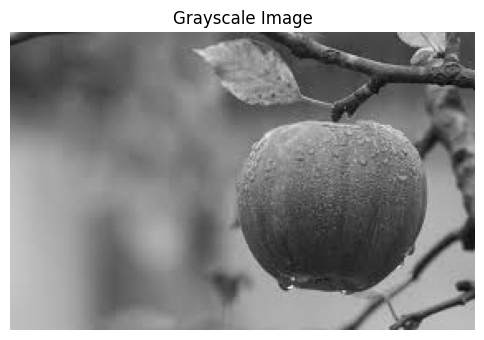

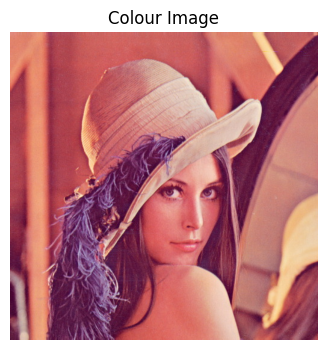

In [7]:
show(gray_img, "Grayscale Image")
show(color_img, "Colour Image")

### Binarize a test image

In [8]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("images/apple.jpg")

In [9]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

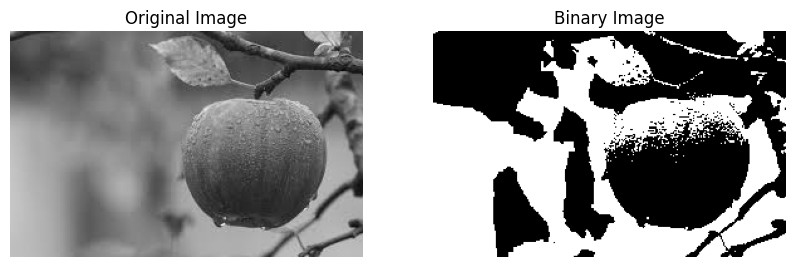

In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.show()

### Apply the four morphological operations

In [11]:
kernel = np.ones((5, 5), np.uint8)

print(kernel)

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


In [12]:
eroded = cv2.erode(binary, kernel, iterations=1)

dilated = cv2.dilate(binary, kernel, iterations=1)

opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

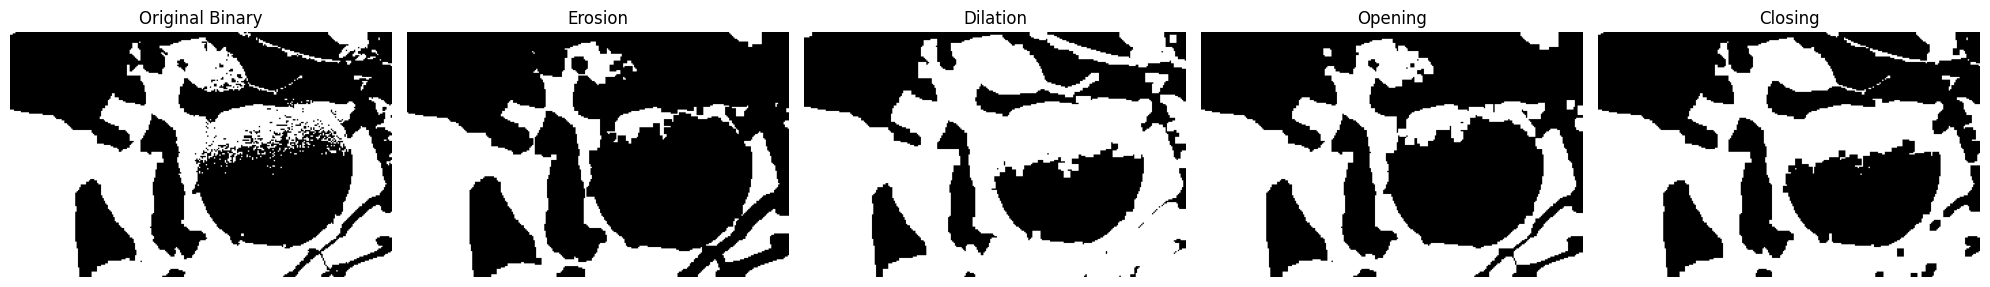

In [13]:
plt.figure(figsize=(20, 4))

plt.subplot(1, 5, 1)
plt.imshow(binary, cmap="gray")
plt.title("Original Binary")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(eroded, cmap="gray")
plt.title("Erosion")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(dilated, cmap="gray")
plt.title("Dilation")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(opened, cmap="gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(closed, cmap="gray")
plt.title("Closing")
plt.axis("off")

plt.tight_layout()
plt.show()

### Kernel shape & size comparison

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("images/coins.png", cv2.IMREAD_GRAYSCALE)

print(img.shape)

(1086, 1448)


In [26]:
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

In [21]:
noisy_binary = binary.copy()

# Salt noise
salt = np.random.random(binary.shape) < 0.02
noisy_binary[salt] = 255

# Pepper noise
pepper = np.random.random(binary.shape) < 0.02
noisy_binary[pepper] = 0

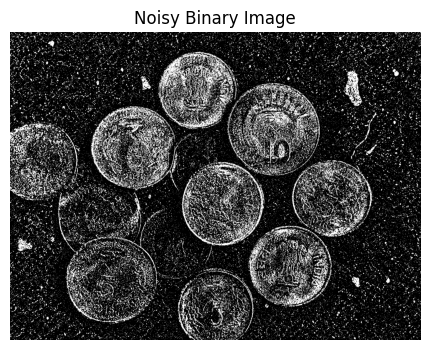

In [22]:
plt.figure(figsize=(6, 4))

plt.imshow(noisy_binary, cmap="gray")
plt.title("Noisy Binary Image")
plt.axis("off")

plt.show()

In [23]:
shapes = {
    "Rectangle": cv2.MORPH_RECT,
    "Ellipse": cv2.MORPH_ELLIPSE,
    "Cross": cv2.MORPH_CROSS
}

sizes = [3, 5, 9]

In [24]:
results = {}

for shape_name, shape_type in shapes.items():
    for size in sizes:
        kernel = cv2.getStructuringElement(shape_type, (size, size))

        opened = cv2.morphologyEx(noisy_binary, cv2.MORPH_OPEN, kernel)
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

        results[f"{shape_name} {size}x{size}"] = closed

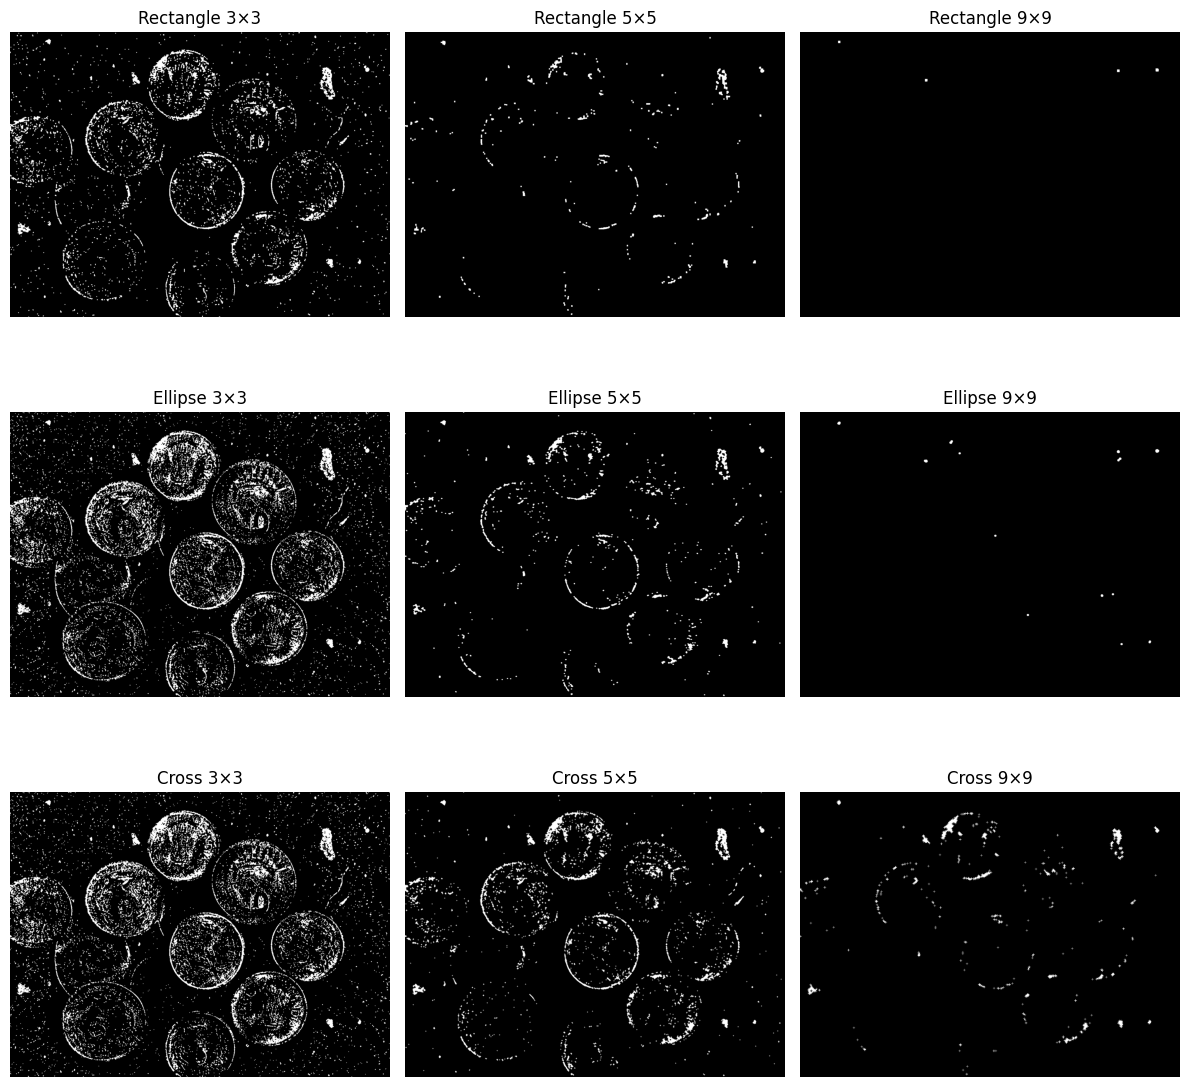

In [25]:
plt.figure(figsize=(12, 12))

plot_no = 1

for shape_name, shape_type in shapes.items():
    for size in sizes:
        result = results[f"{shape_name} {size}x{size}"]

        plt.subplot(3, 3, plot_no)
        plt.imshow(result, cmap="gray")
        plt.title(f"{shape_name} {size}×{size}")
        plt.axis("off")

        plot_no += 1

plt.tight_layout()
plt.show()

### WHY morphology works — Markdown


WHY morphology works :

- **Erosion** is a local minimum filter. It shrinks white regions and removes small bright noise.
- **Dilation** is a local maximum filter. It grows white regions and fills small dark gaps.
- **Opening = Erosion → Dilation**. It removes small noise while preserving the overall shape and size.
- **Closing = Dilation → Erosion**. It fills small holes without shrinking the object.

Real-world scenarios :

- **Erosion:** Remove small bright noise from a segmentation mask before object detection.
- **Dilation:** Fill small gaps in a detected object mask before passing it to a detector.
- **Opening:** Remove small unwanted objects/noise from a mask before downstream detection.
- **Closing:** Fill small holes or gaps inside an object mask before downstream detection.

## Task 2: Bitwise Operations & Image Histograms


### Bitwise AND / OR / XOR / NOT

In [28]:
mask1 = np.zeros((300, 300), dtype=np.uint8)
mask2 = np.zeros((300, 300), dtype=np.uint8)

cv2.circle(mask1, (130, 150), 80, 255, -1)
cv2.rectangle(mask2, (100, 80), (240, 220), 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(300, 300), dtype=uint8)

In [29]:
and_result = cv2.bitwise_and(mask1, mask2)
or_result = cv2.bitwise_or(mask1, mask2)
xor_result = cv2.bitwise_xor(mask1, mask2)
not_result = cv2.bitwise_not(mask1)

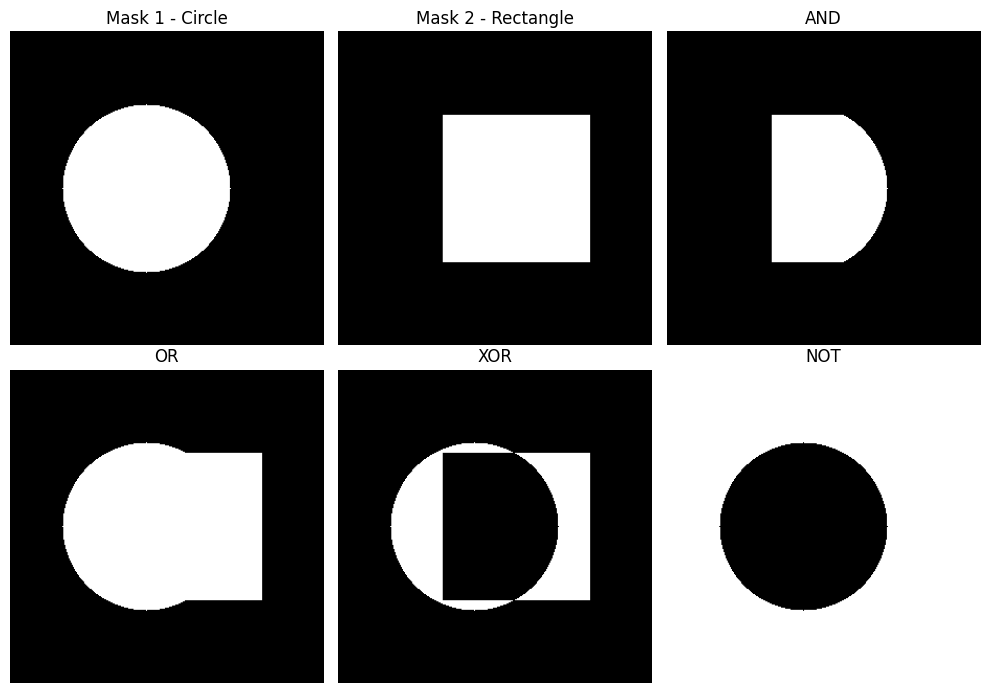

In [30]:
plt.figure(figsize=(10, 7))

plt.subplot(2, 3, 1)
plt.imshow(mask1, cmap="gray")
plt.title("Mask 1 - Circle")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(mask2, cmap="gray")
plt.title("Mask 2 - Rectangle")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(and_result, cmap="gray")
plt.title("AND")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(or_result, cmap="gray")
plt.title("OR")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(xor_result, cmap="gray")
plt.title("XOR")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(not_result, cmap="gray")
plt.title("NOT")
plt.axis("off")

plt.tight_layout()
plt.show()

### Applied use-case: masked overlay


In [44]:
photo = cv2.imread("images/lena.jpg")

In [45]:
mask = np.zeros(photo.shape[:2], dtype=np.uint8)

cv2.circle(
    mask,
    (photo.shape[1] // 2, photo.shape[0] // 2),
    150,
    255,
    -1
)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(512, 512), dtype=uint8)

In [ ]:
masked_region = cv2.bitwise_and(photo, photo, mask=mask)

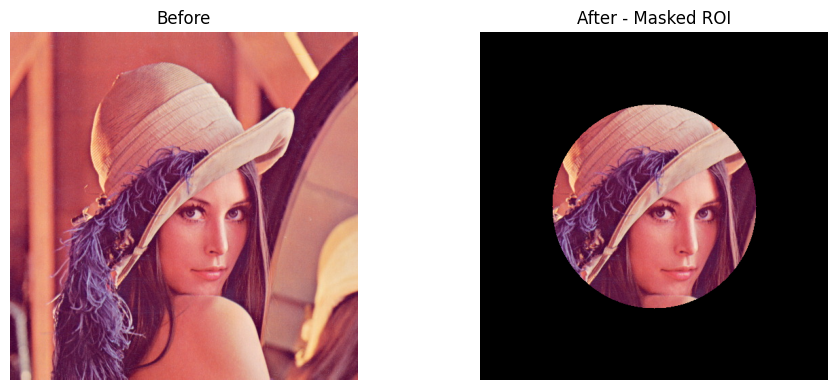

In [48]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(photo, cv2.COLOR_BGR2RGB))
plt.title("Before")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(masked_region, cv2.COLOR_BGR2RGB))
plt.title("After - Masked ROI")
plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
logo = cv2.imread("images/solid.png")
logo = cv2.resize(logo, (100, 100))

overlay = photo.copy()
overlay[20:120, 20:120] = cv2.bitwise_or(
    overlay[20:120, 20:120],
    logo
)

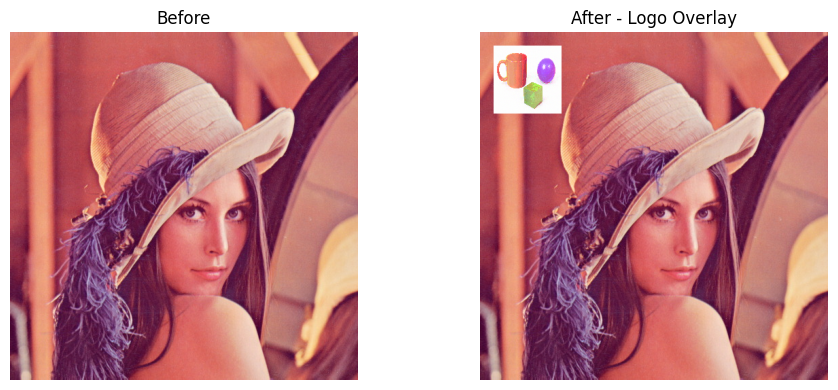

In [50]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(photo, cv2.COLOR_BGR2RGB))
plt.title("Before")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("After - Logo Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

### Grayscale & per-channel colour histograms


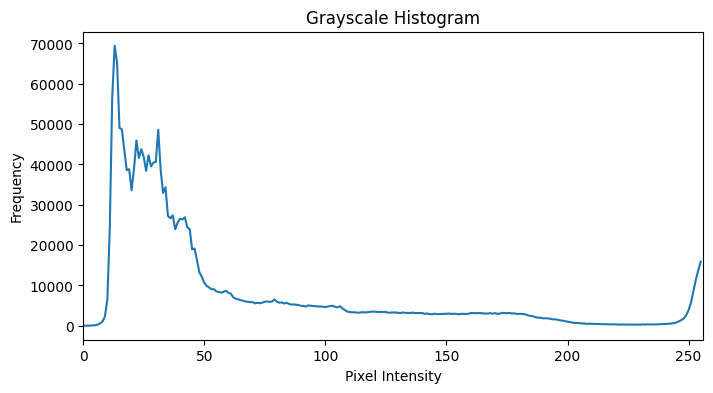

In [57]:
gray = cv2.imread("images/leaves.jpg", cv2.IMREAD_GRAYSCALE)

gray_hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 4))
plt.plot(gray_hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.show()

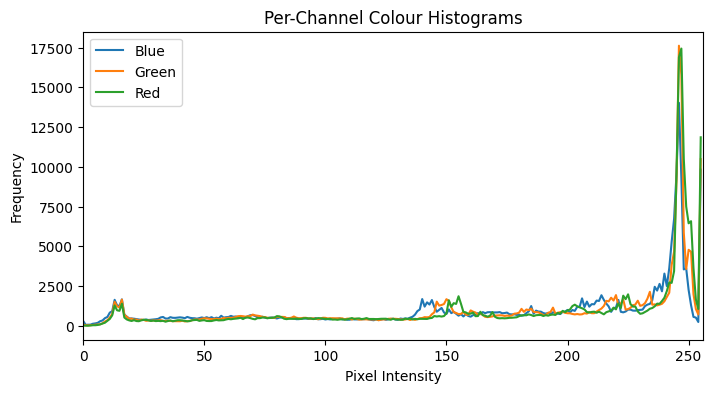

In [58]:
color = cv2.imread("images/person.jpg")

blue_hist = cv2.calcHist([color], [0], None, [256], [0, 256])
green_hist = cv2.calcHist([color], [1], None, [256], [0, 256])
red_hist = cv2.calcHist([color], [2], None, [256], [0, 256])

plt.figure(figsize=(8, 4))
plt.plot(blue_hist, label="Blue")
plt.plot(green_hist, label="Green")
plt.plot(red_hist, label="Red")

plt.title("Per-Channel Colour Histograms")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.show()

### Brightness & contrast adjustment


(0.0, 256.0)

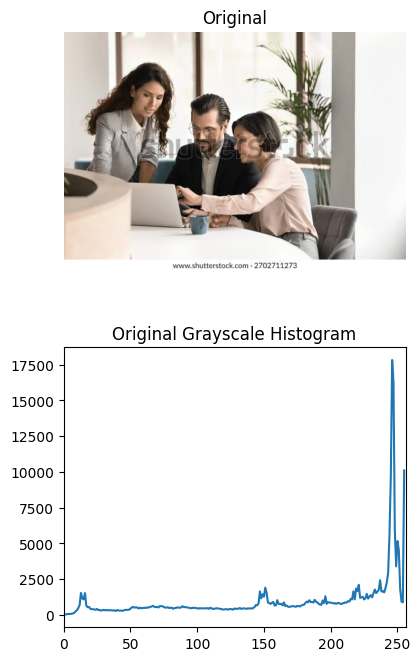

In [59]:
img = cv2.imread("images/person.jpg")

# Adjust brightness and contrast
brightened = cv2.convertScaleAbs(img, alpha=1.5, beta=30)
darkened = cv2.convertScaleAbs(img, alpha=0.7, beta=-30)

# Convert to grayscale
gray_original = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_brightened = cv2.cvtColor(brightened, cv2.COLOR_BGR2GRAY)
gray_darkened = cv2.cvtColor(darkened, cv2.COLOR_BGR2GRAY)

# Histograms
hist_original = cv2.calcHist([gray_original], [0], None, [256], [0, 256])
hist_brightened = cv2.calcHist([gray_brightened], [0], None, [256], [0, 256])
hist_darkened = cv2.calcHist([gray_darkened], [0], None, [256], [0, 256])

# Display images with histograms below
plt.figure(figsize=(15, 8))

# Original
plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.plot(hist_original)
plt.title("Original Grayscale Histogram")
plt.xlim([0, 256])


(0.0, 256.0)

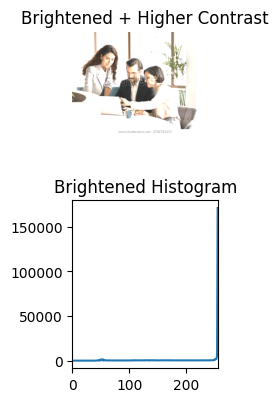

In [60]:
# Brightened
plt.subplot(2, 3, 2)
plt.imshow(cv2.cvtColor(brightened, cv2.COLOR_BGR2RGB))
plt.title("Brightened + Higher Contrast")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.plot(hist_brightened)
plt.title("Brightened Histogram")
plt.xlim([0, 256])

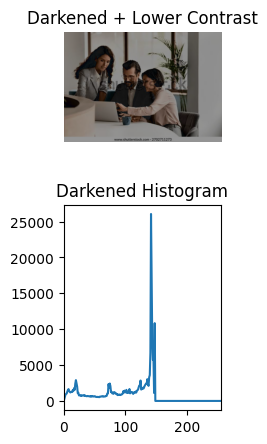

In [61]:
# Darkened
plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(darkened, cv2.COLOR_BGR2RGB))
plt.title("Darkened + Lower Contrast")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.plot(hist_darkened)
plt.title("Darkened Histogram")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

### WHY alpha/beta and histograms matter — Markdown


WHY alpha/beta and histograms matter :

The brightness and contrast adjustment follows:

**new_pixel = alpha × pixel + beta**

- **Alpha (α)** controls contrast. Higher alpha stretches the histogram, while lower alpha compresses it.
- **Beta (β)** controls brightness. Positive beta shifts the histogram to the right (brighter), while negative beta shifts it to the left (darker).
- A **narrow histogram** indicates low contrast or a washed-out image.
- A histogram **clipped at 0 or 255** indicates under-exposure or over-exposure.
- This histogram view helps determine whether an image needs pre-processing before being given to face/object detectors.

## Task 3: Face Detection with YuNet (OpenCV 5.0)


### Load the YuNet face detector

In [63]:
import cv2
img = cv2.imread("images/person.jpg")

img_h, img_w = img.shape[:2]

detector = cv2.FaceDetectorYN_create(
    "face_detection_yunet_2023mar.onnx",
    "",
    (img_w, img_h),
    score_threshold=0.9
)
detector.setInputSize((img_w, img_h))

_, faces = detector.detect(img)

print("Detected Faces:", 0 if faces is None else len(faces))

Detected Faces: 2


### Detect on static images


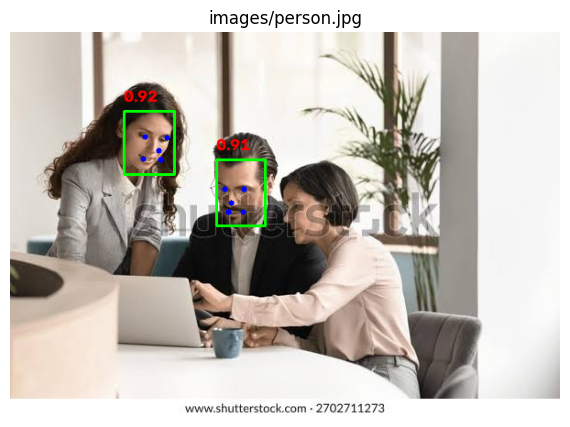

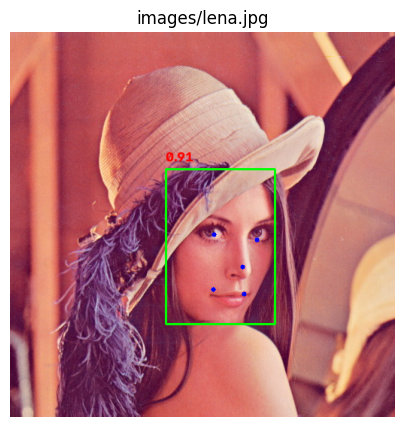

In [ ]:
import cv2
import matplotlib.pyplot as plt

image_paths = [
    "images/person.jpg",
    "images/lena.jpg",
]

for path in image_paths:
    img = cv2.imread(path)

    img_h, img_w = img.shape[:2]
    
    detector.setInputSize((img_w, img_h))
    _, faces = detector.detect(img)

    output = img.copy()

    if faces is not None:
        for face in faces:
            x, y, w, h = face[:4].astype(int)

            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

            landmarks = face[4:14].reshape(5, 2).astype(int)

            for px, py in landmarks:
                cv2.circle(output, (px, py), 3, (255, 0, 0), -1)

            score = face[14]
            cv2.putText(output, f"{score:.2f}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title(path)
    plt.axis("off")
    plt.show()

### Real-time detection on webcam


In [69]:
import cv2
import time

cap = cv2.VideoCapture(0)

prev_size = None
frame_count = 0
start_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w = frame.shape[:2]

    if prev_size != (w, h):
        detector.setInputSize((w, h))
        prev_size = (w, h)

    _, faces = detector.detect(frame)

    if faces is not None:
        for face in faces:
            x, y, fw, fh = face[:4].astype(int)

            cv2.rectangle(frame, (x, y), (x + fw, y + fh), (0, 255, 0), 2)

            landmarks = face[4:14].reshape(5, 2).astype(int)

            for px, py in landmarks:
                cv2.circle(frame, (px, py), 3, (255, 0, 0), -1)

            score = face[14]
            cv2.putText(frame, f"{score:.2f}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255),2)

    frame_count += 1
    elapsed = time.time() - start_time
    fps = frame_count / elapsed

    cv2.putText( frame, f"FPS: {fps:.2f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0),2)

    cv2.imshow("YuNet Real-Time Face Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

print(f"Achieved FPS: {fps:.2f}")

Achieved FPS: 28.94


### Score-threshold experiment & applied privacy use-case

In [71]:
img = cv2.imread("images/person.jpg")
h, w = img.shape[:2]

for threshold in [0.5, 0.7, 0.9]:
    detector = cv2.FaceDetectorYN_create(
        "face_detection_yunet_2023mar.onnx", "", (w, h),
        score_threshold=threshold
    )
    detector.setInputSize((w, h))
    _, faces = detector.detect(img)

    print(f"Threshold {threshold}: Detected Faces = {0 if faces is None else len(faces)}")

detector = cv2.FaceDetectorYN_create(
    "face_detection_yunet_2023mar.onnx", "", (w, h),
    score_threshold=0.9
)
detector.setInputSize((w, h))
_, faces = detector.detect(img)

blurred = img.copy()

if faces is not None:
    for face in faces:
        x, y, fw, fh = face[:4].astype(int)
        blurred[y:y+fh, x:x+fw] = cv2.GaussianBlur(
            blurred[y:y+fh, x:x+fw], (51, 51), 0
        )


Threshold 0.5: Detected Faces = 3
Threshold 0.7: Detected Faces = 3
Threshold 0.9: Detected Faces = 2


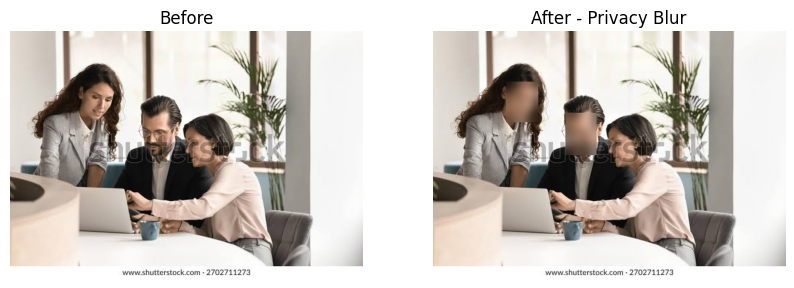

In [72]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Before")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
plt.title("After - Privacy Blur")
plt.axis("off")

plt.show()

### WHY YuNet — Markdown

WHY YuNet :

YuNet is a compact, modern CNN-based face detector recommended in OpenCV 5.0 through `cv2.FaceDetectorYN`. It is trained on diverse, in-the-wild faces, so it can generalise well to profile views, partial occlusion, and small or blurry faces. It also returns 5-point facial landmarks in a single forward pass.

The `score_threshold` controls the trade-off between missed detections and false positives. A **lower threshold (0.5–0.7)** detects more faces but may increase false positives, while a **higher threshold (0.9)** is more selective and may miss difficult faces. For a **real-time security camera**, I would choose around **0.7** for a balance between detection and false positives. For an **offline photo-tagging tool**, I would choose around **0.5–0.7** to reduce missed faces.

## Task 4: Object Detection with YOLO


### Load pretrained YOLOv8 & run on static images



image 1/1 c:\AI - ML DS\AI - ML Ds\Deep learning\Project\PR-3\images\person.jpg: 448x640 3 persons, 1 cup, 2 chairs, 1 couch, 1 potted plant, 66.6ms
Speed: 2.9ms preprocess, 66.6ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


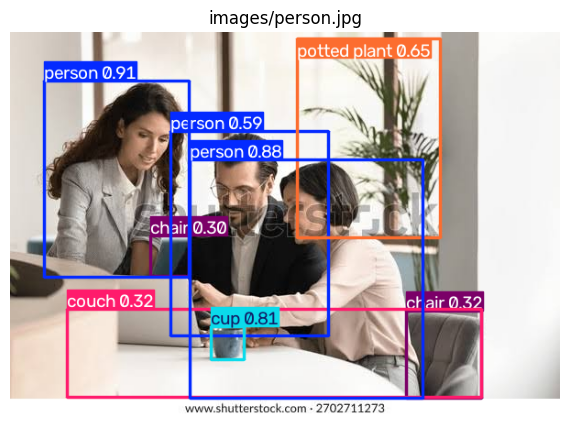


image 1/1 c:\AI - ML DS\AI - ML Ds\Deep learning\Project\PR-3\images\chair.jpg: 640x640 1 bench, 1 chair, 1 potted plant, 82.3ms
Speed: 7.2ms preprocess, 82.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


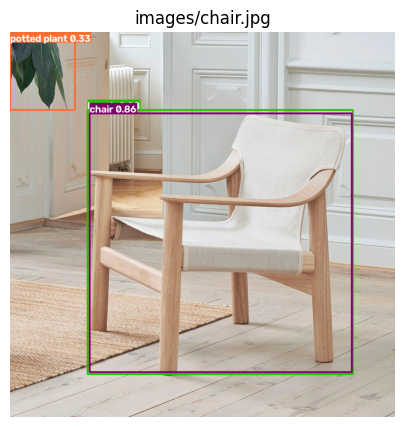


image 1/1 c:\AI - ML DS\AI - ML Ds\Deep learning\Project\PR-3\images\lena.jpg: 640x640 1 person, 1 umbrella, 100.1ms
Speed: 4.4ms preprocess, 100.1ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


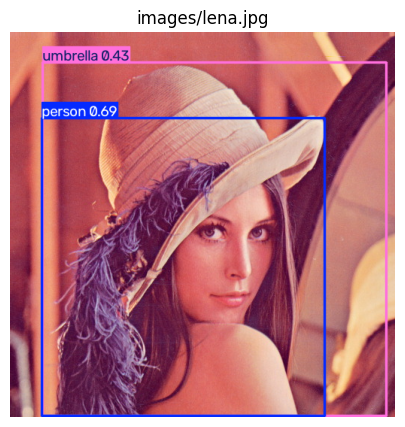

In [77]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("yolov8n.pt")

image_paths = [
    "images/person.jpg",
    "images/chair.jpg",
    "images/lena.jpg"
]

for image_path in image_paths:
    results = model(image_path)
    output = results[0].plot()

    plt.figure(figsize=(8, 5))
    plt.imshow(output[:, :, ::-1])
    plt.title(image_path)
    plt.axis("off")
    plt.show()

### Real-time YOLO on webcam


In [79]:
import cv2
import time
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
cap = cv2.VideoCapture(0)

frame_count = 0
start_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, verbose=False)
    annotated_frame = results[0].plot()

    frame_count += 1
    elapsed = time.time() - start_time
    fps = frame_count / elapsed

    cv2.putText(annotated_frame, f"FPS: {fps:.2f}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    cv2.imshow("Real-Time YOLOv8", annotated_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

print(f"Achieved FPS: {fps:.2f}")

Achieved FPS: 12.73


### Confidence & IoU threshold tuning


In [86]:
model = YOLO("yolov8n.pt")
image_path = "images/person.jpg"

conf_values = [0.25, 0.5, 0.75]
iou_values = [0.3, 0.5, 0.7]

conf_counts = []
iou_counts = []

for conf in conf_values:
    results = model(image_path, conf=conf, iou=0.5, verbose=False)
    conf_counts.append(len(results[0].boxes))

for iou in iou_values:
    results = model(image_path, conf=0.25, iou=iou, verbose=False)
    iou_counts.append(len(results[0].boxes))

low_iou = model(image_path, conf=0.25, iou=0.3, verbose=False)
high_iou = model(image_path, conf=0.25, iou=0.7, verbose=False)

low_iou_img = low_iou[0].plot()
high_iou_img = high_iou[0].plot()



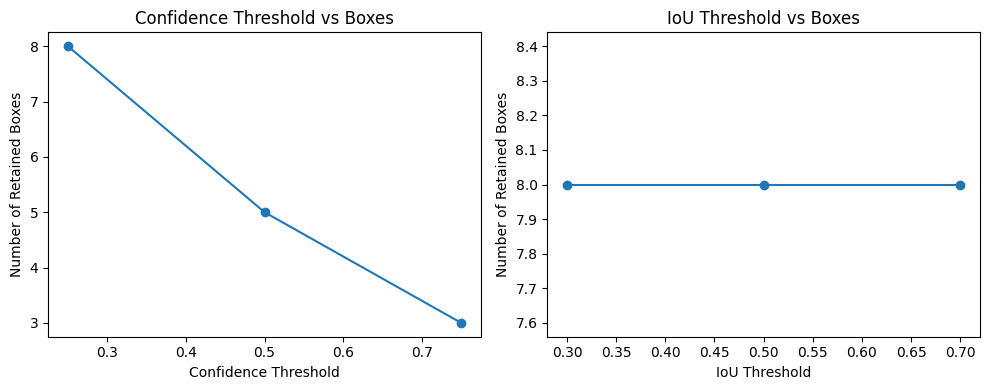

In [87]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(conf_values, conf_counts, marker="o")
plt.xlabel("Confidence Threshold")
plt.ylabel("Number of Retained Boxes")
plt.title("Confidence Threshold vs Boxes")

plt.subplot(1, 2, 2)
plt.plot(iou_values, iou_counts, marker="o")
plt.xlabel("IoU Threshold")
plt.ylabel("Number of Retained Boxes")
plt.title("IoU Threshold vs Boxes")

plt.tight_layout()
plt.show()


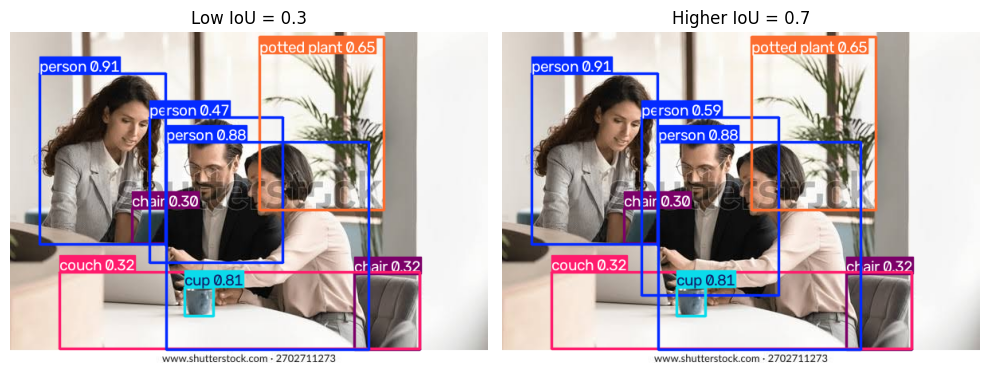

In [88]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(low_iou_img, cv2.COLOR_BGR2RGB))
plt.title("Low IoU = 0.3")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(high_iou_img, cv2.COLOR_BGR2RGB))
plt.title("Higher IoU = 0.7")
plt.axis("off")

plt.tight_layout()
plt.show()

### Per-class detection summary


Per-Class Detection Summary:
person: 4
cup: 1
potted plant: 2
couch: 1
chair: 3
bench: 1
umbrella: 1


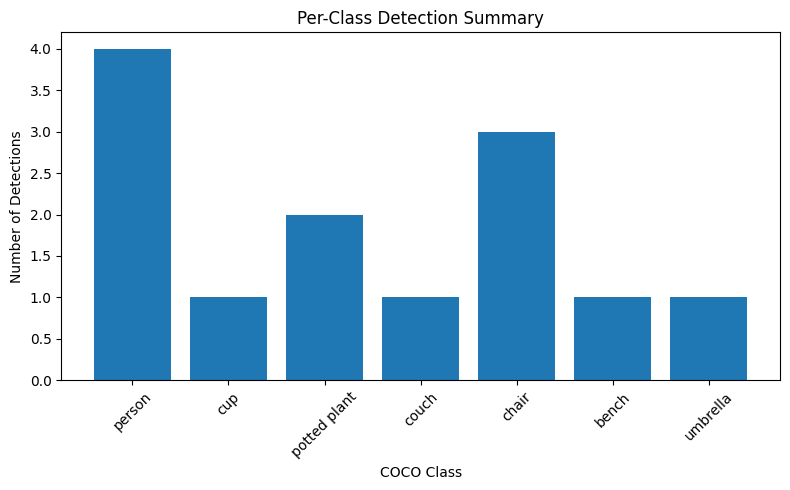


Missed/Misclassified Classes:
Possible reasons: occlusion, small object size, unusual viewing angle, blur, or low image quality.


In [93]:
from collections import Counter

model = YOLO("yolov8n.pt")

image_paths = [
    "images/person.jpg",
    "images/chair.jpg",
    "images/lena.jpg"
]

class_counts = Counter()

for image_path in image_paths:
    results = model(image_path, verbose=False)

    for cls in results[0].boxes.cls:
        class_name = model.names[int(cls)]
        class_counts[class_name] += 1

print("Per-Class Detection Summary:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("COCO Class")
plt.ylabel("Number of Detections")
plt.title("Per-Class Detection Summary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nMissed/Misclassified Classes:")
print("Possible reasons: occlusion, small object size, unusual viewing angle, blur, or low image quality.")

### WHY YOLO generalises — Markdown


WHY YOLO generalises :

YOLO uses a **single-stage, grid-based design**. The image is divided into a grid, and each cell directly predicts bounding boxes and class probabilities in one forward pass. **Non-Max Suppression (NMS)** then removes duplicate overlapping detections.

The **YOLOv8n (nano)** model is faster and uses fewer resources, but it is generally less accurate than the larger **YOLOv8s, m, l, and x** variants. Larger models provide better accuracy at the cost of more computation and slower inference.

A single pretrained YOLOv8 model can detect **80 COCO object classes** because it was trained on all these classes together. The learned features are shared across classes, so no separate model or per-class hand-tuning is required.

## Task 5: Integrated Pipeline & Final Comparison


### Build the unified pipeline


In [94]:
model = YOLO("yolov8n.pt")

detector = cv2.FaceDetectorYN_create(
    "face_detection_yunet_2023mar.onnx",
    "",
    (640, 480),
    score_threshold=0.7
)

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w = frame.shape[:2]
    detector.setInputSize((w, h))

    _, faces = detector.detect(frame)

    if faces is not None:
        for face in faces:
            x, y, fw, fh = face[:4].astype(int)

            cv2.rectangle(frame, (x, y), (x + fw, y + fh),(0, 255, 0), 2)
            cv2.putText(frame, "Face", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    results = model(frame, verbose=False)

    for box in results[0].boxes:
        x1, y1, x2, y2 = box.xyxy[0].int().tolist()
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        label = f"{model.names[cls]} {conf:.2f}"

        cv2.rectangle(frame, (x1, y1), (x2, y2),(0, 0, 255), 2)
        cv2.putText(frame, label, (x1, y1 - 10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    cv2.imshow("YuNet + YOLO Unified Pipeline", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

### Morphological pre-cleaning


In [96]:
model = YOLO("yolov8n.pt")
cap = cv2.VideoCapture(0)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    results_original = model(frame, verbose=False)
    count_original = len(results_original[0].boxes)

    opened = cv2.morphologyEx(frame, cv2.MORPH_OPEN, kernel)
    results_opened = model(opened, verbose=False)
    count_opened = len(results_opened[0].boxes)

    output_original = results_original[0].plot()
    output_opened = results_opened[0].plot()

    cv2.putText(output_original, f"Without Opening: {count_original}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    cv2.putText(output_opened, f"With Opening: {count_opened}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    combined = cv2.hconcat([output_original, output_opened])
    cv2.imshow("Morphological Pre-cleaning Comparison", combined)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

### FPS benchmarking


In [97]:
import time
model = YOLO("yolov8n.pt")

detector = cv2.FaceDetectorYN_create(
    "face_detection_yunet_2023mar.onnx",
    "",
    (640, 480),
    score_threshold=0.7
)
cap = cv2.VideoCapture(0)

face_times = []
yolo_times = []
combined_times = []
frames = []

for _ in range(100):
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)

cap.release()

for frame in frames:
    h, w = frame.shape[:2]
    detector.setInputSize((w, h))

    start = time.time()
    detector.detect(frame)
    face_times.append(time.time() - start)

# YOLO alone
for frame in frames:
    start = time.time()
    model(frame, verbose=False)
    yolo_times.append(time.time() - start)

# Full combined pipeline
for frame in frames:
    h, w = frame.shape[:2]
    detector.setInputSize((w, h))

    start = time.time()

    detector.detect(frame)
    model(frame, verbose=False)

    combined_times.append(time.time() - start)

face_fps = 1 / (sum(face_times) / len(face_times))
yolo_fps = 1 / (sum(yolo_times) / len(yolo_times))
combined_fps = 1 / (sum(combined_times) / len(combined_times))

print(f"Face Detection FPS: {face_fps:.2f}")
print(f"YOLO FPS: {yolo_fps:.2f}")
print(f"Combined Pipeline FPS: {combined_fps:.2f}")

labels = ["Face Detection", "YOLO", "Combined Pipeline"]
fps_values = [face_fps, yolo_fps, combined_fps]

Face Detection FPS: 21.54
YOLO FPS: 10.15
Combined Pipeline FPS: 6.19


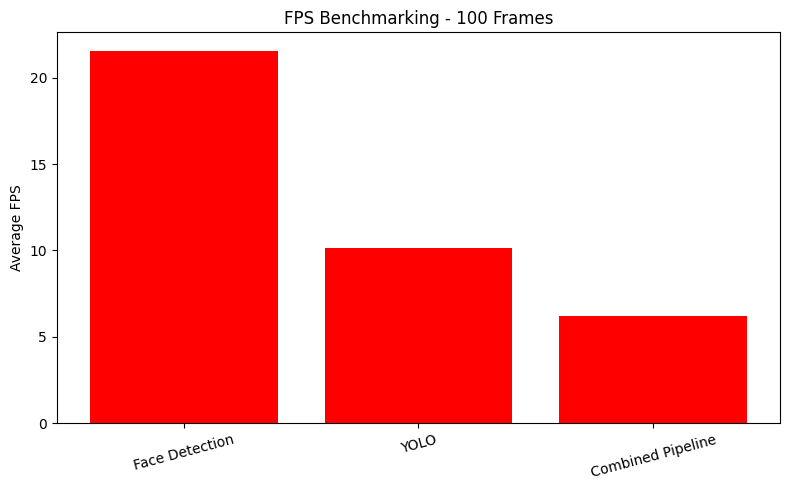

In [99]:
plt.figure(figsize=(8, 5))
plt.bar(labels, fps_values, color='red')
plt.ylabel("Average FPS")
plt.title("FPS Benchmarking - 100 Frames")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Final results comparison table


| Technique | Type | What It Detects | Lighting Robustness | Approx. FPS | Best Use Case |
|---|---|---|---|---|---|
| Morphology | Classical | Shapes, regions, noise | Low–Medium | Very High | Image pre-processing and noise removal |
| Bitwise / Histograms | Classical | Pixel regions and intensity distribution | Low–Medium | Very High | Masking, image analysis, brightness/contrast checking |
| YuNet Face Detection | Deep Learning | Human faces + 5 facial landmarks | High | High | Real-time face detection |
| YOLOv8n | Deep Learning | 80 COCO object classes | High | High | Real-time multi-object detection |

### Reflection — Markdown


Reflection :

For real-time monitoring, the best accuracy-to-compute trade-off is **light classical pre-processing such as morphology/histogram-based enhancement followed by YuNet for faces and YOLOv8n for objects**. This combination provides good detection performance while maintaining high FPS.

On a **low-power edge device**, I would keep **YOLOv8n**, use light pre-processing, and adjust the **YuNet score_threshold to around 0.7** for a balance between speed, missed detections, and false positives. On a **cloud server**, I would consider **YOLOv8s** for better accuracy and use a higher YuNet threshold such as **0.8–0.9** when fewer false positives are preferred.